In [1]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pickle
import numpy as np
import os

class CustomCIFAR10(Dataset):
    def __init__(self, data_path, train=True, transform=None):
        self.transform = transform
        self.data = []
        self.targets = []
        
        # CIFAR-10 data files (batches)
        files = [f'data_batch_{i}' for i in range(1, 6)] if train else ['test_batch']
        
        for file_name in files:
            path = os.path.join(data_path, file_name)
            with open(path, 'rb') as f:
                entry = pickle.load(f, encoding='latin1')
                self.data.append(entry['data'])
                self.targets.extend(entry['labels'])
        
        self.data = np.vstack(self.data).reshape(-1, 3, 32, 32).transpose((0, 2, 3, 1))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img, target = self.data[idx], self.targets[idx]
        if self.transform:
            img = self.transform(img)
        return img, target

In [2]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layer = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layer = nn.Sequential(
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layer(x)
        return x

In [3]:
from fvcore.nn import FlopCountAnalysis

model = SimpleCNN()
inputs = torch.randn(1, 3, 32, 32)
flops = FlopCountAnalysis(model, inputs)
print(f"Total FLOPs: {flops.total()}")

Unsupported operator aten::max_pool2d encountered 2 time(s)


Total FLOPs: 7705600


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
import wget
import tarfile
import os

# Create the directory
os.makedirs('data/', exist_ok=True)

# URL for the Python version of CIFAR-10
url = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
filename = "data/cifar-10-python.tar.gz"

# Download
if not os.path.exists(filename):
    print("Downloading CIFAR-10...")
    wget.download(url, out=filename)
    print("\nDownload complete.")

# Extract
print("Extracting files...")
with tarfile.open(filename, "r:gz") as tar:
    tar.extractall(path="data/")
print("Extraction complete. Your path 'data/cifar-10-batches-py' should now work!")

100% [..................................................] 170498071 / 170498071
Download complete.
Extracting files...
Extraction complete. Your path 'data/cifar-10-batches-py' should now work!


In [6]:
from torchvision import transforms

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 1. Instantiate the Custom Dataset
# Ensure 'data_path' points to the folder containing 'data_batch_1', etc.
train_dataset = CustomCIFAR10(data_path='data/cifar-10-batches-py', train=True, transform=transform)

# 2. Define the train_loader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [7]:
import wandb

# 1. Initialize Wandb
wandb.init(project="lab2_assignment", name="cnn_cifar10")

# 2. Setup training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 3. Watch model (Gradients and Weights)
wandb.watch(model, log="all", log_freq=10)

# 4. Training Loop (25-30 Epochs)
for epoch in range(25):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
    wandb.log({"epoch": epoch, "loss": loss.item()})

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: m23cse012 to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/home/deepraj/.local/lib/python3.10/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wandb

# Initialize API
api = wandb.Api()

# Replace with your specific run path: "entity/project/run_id"
run = api.run("m23cse012/lab2_assignment/lw03y6aj")

# Get history (Loss, Accuracy, etc.)
history = run.history()

# Get Config and Summary (FLOPs, total epochs)
print(f"Model FLOPs: {run.summary.get('total_flops', 'Not Logged')}")

Model FLOPs: Not Logged


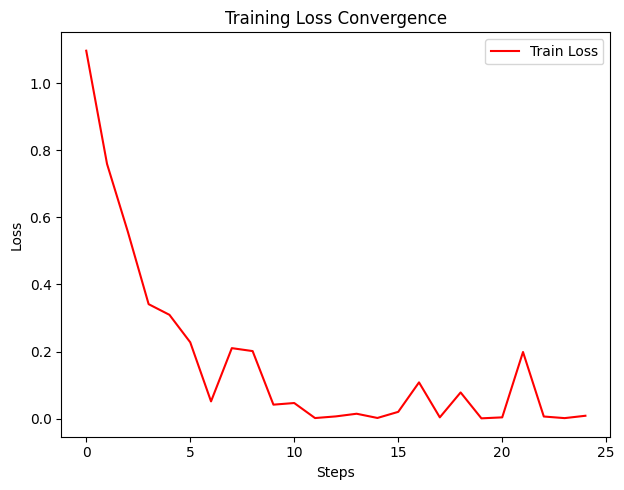

In [9]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
sns.lineplot(data=history, x='_step', y='loss', label='Train Loss', color='red')
plt.title('Training Loss Convergence')
plt.xlabel('Steps')
plt.ylabel('Loss')

# Plot Accuracy (if you logged it)
if 'accuracy' in history.columns:
    plt.subplot(1, 2, 2)
    sns.lineplot(data=history, x='_step', y='accuracy', label='Train Accuracy', color='blue')
    plt.title('Training Accuracy')
    plt.xlabel('Steps')
    plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

In [10]:
# Filtering columns that contain gradient information
grad_cols = [col for col in history.columns if 'gradients' in col and 'norm' in col]

if grad_cols:
    plt.figure(figsize=(10, 6))
    for col in grad_cols:
        plt.plot(history['_step'], history[col], label=col.split('/')[-1])
    
    plt.yscale('log') # Gradients are often very small
    plt.title('Gradient Norm Flow per Layer (Log Scale)')
    plt.xlabel('Steps')
    plt.ylabel('Gradient Norm')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()
else:
    print("No gradient norms found. Ensure wandb.watch(model, log='all') was used.")

No gradient norms found. Ensure wandb.watch(model, log='all') was used.


In [11]:
summary_data = {
    "Metric": ["Total FLOPs", "Final Training Loss", "Total Epochs", "Hardware Used"],
    "Value": [
        run.summary.get("total_flops", "Check fvcore output"),
        round(history['loss'].iloc[-1], 4),
        len(history),
        "CPU (NVML Warning)" if "NVML" in str(run.notes) else "GPU"
    ]
}

df_summary = pd.DataFrame(summary_data)
print(df_summary)

                Metric                Value
0          Total FLOPs  Check fvcore output
1  Final Training Loss               0.0085
2         Total Epochs                   25
3        Hardware Used                  GPU
